# Exam (Base Notebook)

**Instructions**

- Work independently. No AI or other help was used. 
- Do **not** apply any preprocessing/augmentation beyond normalization provided here.
- Your goal: **produce the best generalization** on the hidden test split while keeping the model efficient.
- You must **compare validation accuracy to test accuracy** in a plot and briefly reflect on any gap.
- You may modify only the sections marked **Your work**. Do not change fixed cells.


## 0. Honor Statement
I, `Uzmatul Bushra`, assure that I have completed this exam independently and followed all rules.

In [1]:
# 1) Imports & Reproducibility (Fixed)
import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


In [2]:
# 2) Load Data (Fixed)
# Expects a pickle file 'mnist.hupsista' containing (X, y) as numpy arrays.
with open('mnist.hupsista','rb') as f:
    X_all, y_all = pickle.load(f)

X_all = X_all.astype('float32')
# Normalize to [0,1]
if X_all.max() > 1.0:
    X_all /= 255.0
# Ensure channel dimension
if X_all.ndim == 3:
    X_all = X_all[..., None]

unique_labels = np.unique(y_all)


In [3]:
# 3) Create Train/Val/Test Splits (Fixed)
# Hold-out test once; then split train/val from the remainder.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


Train: (6400, 28, 28, 1) Val: (1600, 28, 28, 1) Test: (2000, 28, 28, 1)


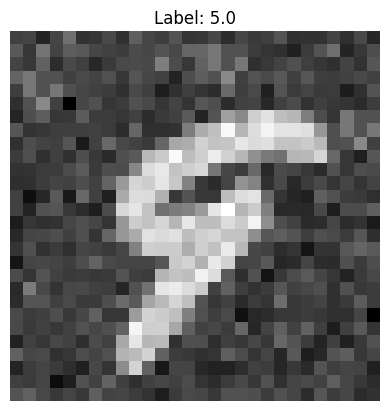

In [4]:
# 4) Quick Visual Check (Fixed)
idx = np.random.randint(0, len(X_train))
plt.imshow(X_train[idx].squeeze(), cmap='gray')
plt.title(f'Label: {y_train[idx]}')
plt.axis('off');plt.show()


## 1. Baseline Model
Check this CNN baseline. Leave as it is. Start fixing it in the next stage.

In [5]:
from tensorflow.keras import layers, models

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(10, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=2, validation_data=(X_val, y_val), verbose=0)
print()

## 2. Learning Curves (Fixed utility)
Plot training vs validation curves to diagnose generalization.

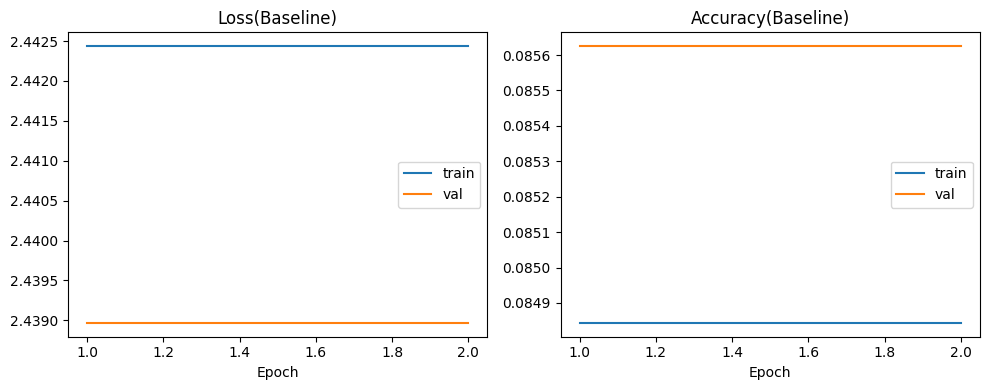

In [6]:
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')


## 3. Validation vs Test Accuracy (Required)
Evaluate on the held-out test set and overlay the test accuracy on the validation curve. Then write a short reflection (3–5 sentences) on the generalization gap.

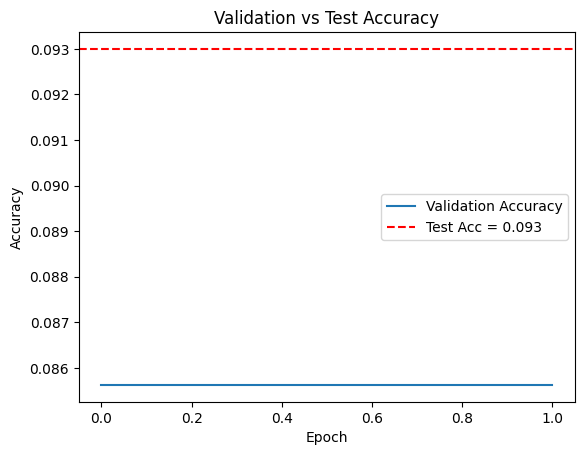

Final Test Accuracy: 0.0930


In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')


### Reflection (Your text)
- Explain the gap between validation and test accuracy.
- What might cause it, and what would you try next to reduce it?
- How much of the dataset do you use for training, validation, and testing? Explain your answer with the % calculation.
- How many images are there in the original dataset?
- How big are the images?
- What observations can you tell about the original data?  
- What are possible labels for the images?
- What are the steps when making models?
- <b>Make sure you explain every step well!<b>
- <b>Make sure your model is as optimized as possible!<b>

## 4. Improved Model (Your work)
Build a better model, train it here as many times as you feel like and when you are pleased with it, title it `final_model`.  Report every try individually, not only the final version.

Explain every step with markdown text and code comments.   

Unrunnable code is not checked. 

In [8]:
# Your work: replace with improved model
final_model = model
final_history = history
print('Final model params:', final_model.count_params())


Final model params: 7850


In [9]:
from tensorflow.keras import layers, models

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(10, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),# changed the optimizer
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=200, validation_data=(X_val, y_val), verbose=0)
print()

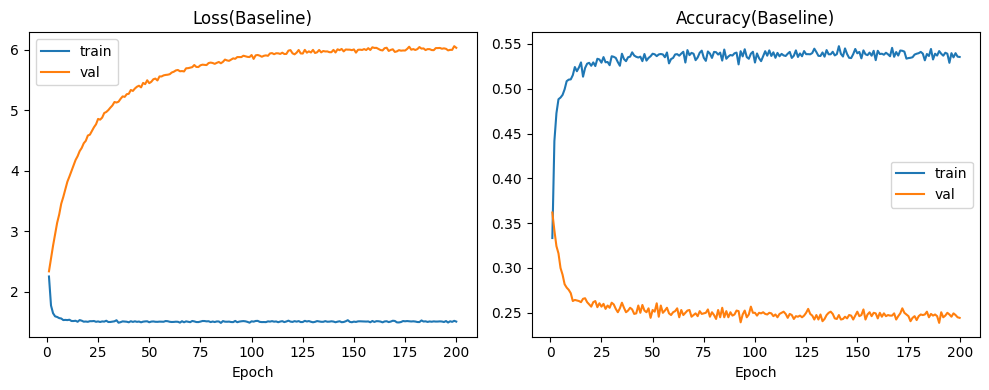

In [10]:
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')


### Changes made:
* changed the optimizer to Adam
* changed the learning raete to o.o1
* Epochs changed to 200

In [21]:
# Create model 2
model_2 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Adding dropout layer for regularization and preventing overfitting
    layers.Dense(10, activation='softmax')
])

# Compile the model
model_2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
history_2 = model_2.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), batch_size=32)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2898 - loss: 2.0764 - val_accuracy: 0.4588 - val_loss: 1.8035
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4322 - loss: 1.7630 - val_accuracy: 0.4981 - val_loss: 1.5775
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4812 - loss: 1.5640 - val_accuracy: 0.5094 - val_loss: 1.4305
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5067 - loss: 1.4410 - val_accuracy: 0.5131 - val_loss: 1.3454
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5300 - loss: 1.3460 - val_accuracy: 0.5312 - val_loss: 1.2962
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5591 - loss: 1.2643 - val_accuracy: 0.5475 - val_loss: 1.2243
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5861 - loss: 1.1815 - val_accuracy: 0.5575 - val_loss: 1.2056
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6055 - loss: 1.1170 - val_accuracy: 0.

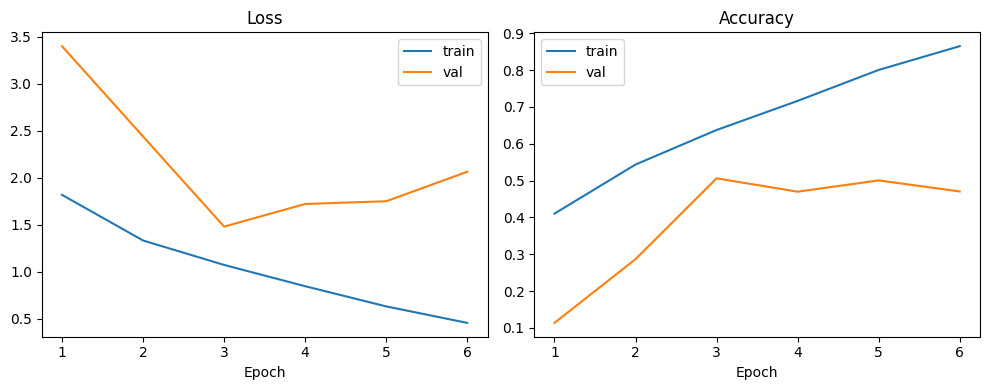

In [25]:
plot_curves(history_2)

In [44]:
# Create model 3
model_3 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),  # stabilize learning
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),

    # Extra Dense layer to learn additional patterns
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(10, activation='softmax')
])

# Compile the model
model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping to prevent overfitting
early_stop_2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Fit the model
history_3 = model_3.fit(
    X_train, y_train,
    epochs=10,  
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop_2]
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4202 - loss: 1.7632 - val_accuracy: 0.1587 - val_loss: 2.6648
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5509 - loss: 1.3167 - val_accuracy: 0.4000 - val_loss: 1.8629
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6284 - loss: 1.0884 - val_accuracy: 0.4850 - val_loss: 1.6212
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7163 - loss: 0.8668 - val_accuracy: 0.4725 - val_loss: 1.6315
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7895 - loss: 0.6516 - val_accuracy: 0.4544 - val_loss: 1.8803
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8462 - loss: 0.4833 - val_accuracy: 0.4613 - val_loss: 1.9131


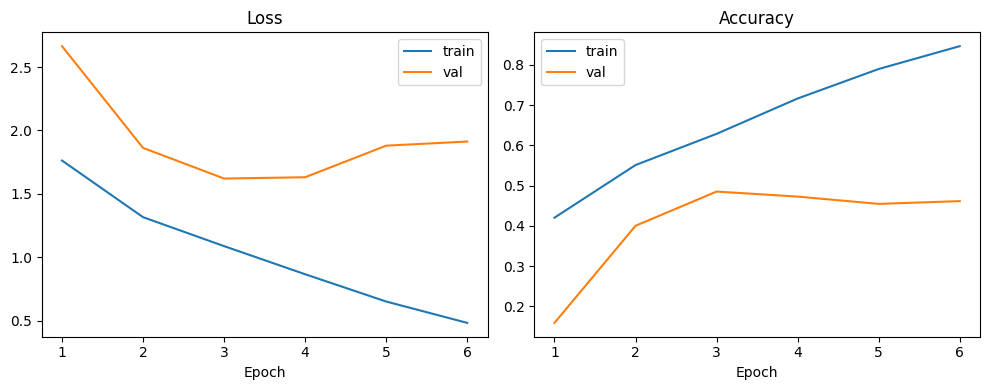

In [45]:
plot_curves(history_3)

### Changes made in model_3

* Added BatchNormalization after Conv2D and Dense layers for stable learning and better accuracy.

* Added extra Dense(64) layer to help the network learn more patterns.

* Added EarlyStopping to prevent overfitting and keep best weights.


In [48]:
# Create model 4
model_4 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),  # stabilize learning
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),

    # Extra Dense layer to learn additional patterns
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(10, activation='softmax')
])

# Compile the model
model_4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping to prevent overfitting
early_stop_2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Fit the model
history_4 = model_4.fit(
    X_train, y_train,
    epochs=20,  # added more more epochs 
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop_2]
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4183 - loss: 1.7899 - val_accuracy: 0.1231 - val_loss: 3.2500
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5272 - loss: 1.3734 - val_accuracy: 0.3356 - val_loss: 1.9427
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5831 - loss: 1.1930 - val_accuracy: 0.4975 - val_loss: 1.4320
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6439 - loss: 1.0231 - val_accuracy: 0.5138 - val_loss: 1.4046
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7237 - loss: 0.8223 - val_accuracy: 0.5050 - val_loss: 1.5125
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7959 - loss: 0.6247 - val_accuracy: 0.4931 - val_loss: 1.8235
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8637 - loss: 0.4499 - val_accuracy: 0.4919 - val_loss: 1.8291


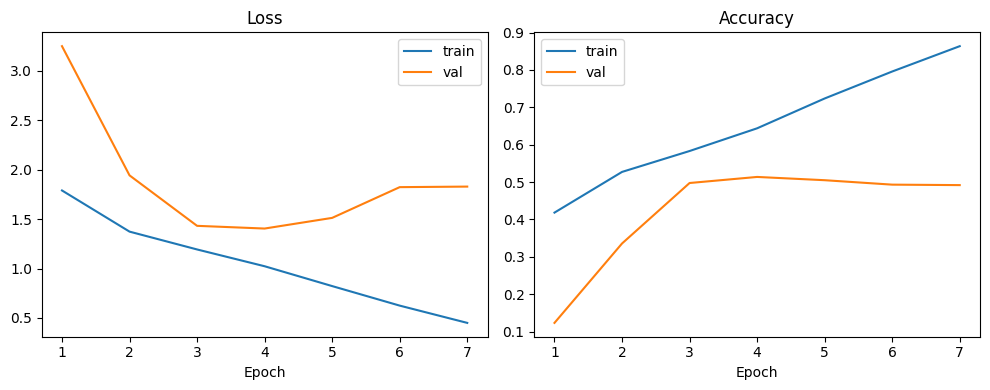

In [49]:
plot_curves(history_4)

### Changes made  in model_4 

* Changed the epochs from 10 to 20

In [53]:
# create model 5
model_5 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),


    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),  # stabilize learning
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),

    # Extra Dense layer to learn additional patterns
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),

    #  Dropout layer for regularization
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(10, activation='softmax')
])

# Compile the model
model_5.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping using full path to avoid NameError
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the model
history_5 = model_5.fit(
    X_train, y_train,
    epochs=50,  # increased epochs for better learning
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3042 - loss: 2.3752 - val_accuracy: 0.0894 - val_loss: 3.6511
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4402 - loss: 1.7825 - val_accuracy: 0.3781 - val_loss: 1.9233
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4947 - loss: 1.5291 - val_accuracy: 0.5169 - val_loss: 1.3899
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5266 - loss: 1.3950 - val_accuracy: 0.5337 - val_loss: 1.3666
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5708 - loss: 1.2550 - val_accuracy: 0.5375 - val_loss: 1.2975
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5956 - loss: 1.1825 - val_accuracy: 0.5225 - val_loss: 1.3380
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6173 - loss: 1.0946 - val_accuracy: 0.5050 - val_loss: 1.3823
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6609 - loss: 0.9922 - val_accu

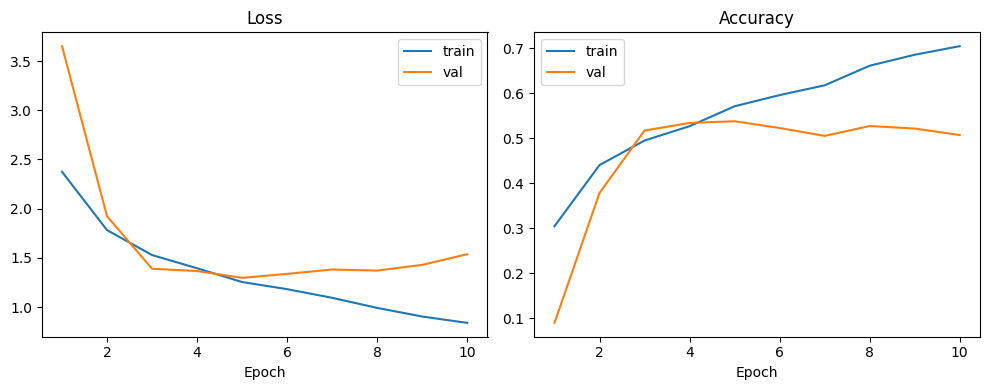

In [54]:
plot_curves(history_5)

### Changes made in model_5 

* Added Dropout(0.5) → helps prevent overfitting, especially on small or custom datasets.

* Increased epochs to 50 

But the accuruacy dropped from before

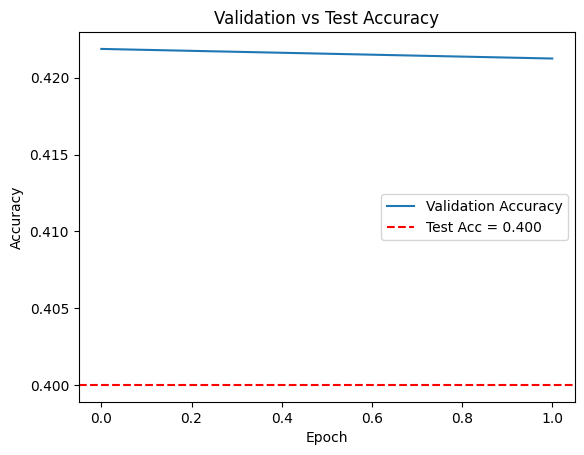

Final Test Accuracy: 0.4000


In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')


# For the improved model of the Validation and Test accuracy:
* added a new layer
* added an activation layer , non-linear funtion ReLu
* changed the learning rate
* changed the optimizer

In [13]:
from tensorflow.keras import layers, models
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    tf.keras.layers.Flatten(),
  
    # tf.keras.layers.Conv2D((16,3) ,activation ='relu'),# added a new layer as in convolutional
    #tf.keras.layers.MaxPool2D(),

    layers.Dense(128,activation='relu'),# added a new layer
    # layers.Dense(128,activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(),#changed the optimmizer
    loss='binary_crossentropy', # changed the loss function as sparse_categorigal_crossentropy works better for label data
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), verbose=0)
print()

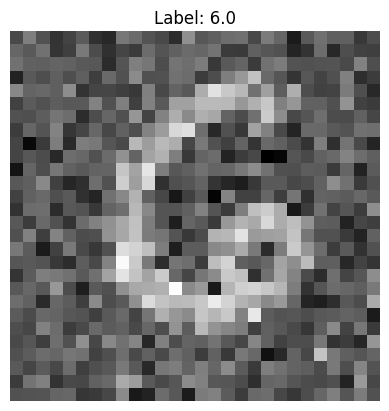

In [14]:
# 4) Quick Visual Check (Fixed)
idx = np.random.randint(0, len(X_train))
plt.imshow(X_train[idx].squeeze(), cmap='gray')
plt.title(f'Label: {y_train[idx]}')
plt.axis('off');plt.show()


## for the optimization of the code :
* the loss function has been changed to binary crossentropy
* optimizer to Adam
* changed the epoch valiu to 50
* for more enhancement I would further add Convolutional layer 
* and would also do Pooling 

In [15]:
# Define the model architecture
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)), #  Take the maximum value in each 2x2 window.
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(), # Convert from 2D matrix into a 1D vector, because Dense layers expect input in this format.
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), batch_size=32)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3684 - loss: 1.9198 - val_accuracy: 0.4900 - val_loss: 1.6811
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4994 - loss: 1.5501 - val_accuracy: 0.4988 - val_loss: 1.5198
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5337 - loss: 1.3720 - val_accuracy: 0.5131 - val_loss: 1.4145
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5683 - loss: 1.2457 - val_accuracy: 0.5256 - val_loss: 1.3647
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6098 - loss: 1.1300 - val_accuracy: 0.5419 - val_loss: 1.3272
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6459 - loss: 1.0177 - val_accuracy: 0.5487 - val_loss: 1.3281
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6869 - loss: 0.9042 - val_accuracy: 0.5606 - val_loss: 1.3224
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7267 - loss: 0.7929 - val_accuracy: 0.

In [17]:
# Define the model architecture
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),  # Take the maximum value in each 2x2 window.

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),  # Convert 2D matrix into 1D vector because Dense layers need 1D input.

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])


# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# EarlyStopping monitors validation loss and stops training if the model
# stops improving. This prevents overfitting and usually improves accuracy.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


# Fit the model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3591 - loss: 1.9355 - val_accuracy: 0.4538 - val_loss: 1.7338
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4936 - loss: 1.5669 - val_accuracy: 0.4994 - val_loss: 1.5304
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5294 - loss: 1.3621 - val_accuracy: 0.5106 - val_loss: 1.3855
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5683 - loss: 1.2231 - val_accuracy: 0.5238 - val_loss: 1.3228
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6122 - loss: 1.0994 - val_accuracy: 0.5375 - val_loss: 1.2836
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6597 - loss: 0.9752 - val_accuracy: 0.5531 - val_loss: 1.2732
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6995 - loss: 0.8563 - val_accuracy: 0.5512 - val_loss: 1.3044
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7412 - loss: 0.7431 - val_accuracy: 0.

In [18]:
# Define the model architecture
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),  # Take the maximum value in each 2x2 window.

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),  # Convert 2D matrix into 1D vector because Dense layers need 1D input.

    layers.Dense(128, activation='relu'),

    # Dropout randomly turns off 30% of neurons during training.
    # This helps prevent overfitting and usually improves validation accuracy.
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])


# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# EarlyStopping monitors validation loss and stops training if the model
# stops improving. This prevents overfitting and usually improves accuracy.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


# Fit the model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3428 - loss: 1.9881 - val_accuracy: 0.4631 - val_loss: 1.7441
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4689 - loss: 1.6597 - val_accuracy: 0.5063 - val_loss: 1.5329
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5109 - loss: 1.4565 - val_accuracy: 0.5175 - val_loss: 1.3820
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5370 - loss: 1.3215 - val_accuracy: 0.5181 - val_loss: 1.3024
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5697 - loss: 1.2111 - val_accuracy: 0.5325 - val_loss: 1.2387
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6022 - loss: 1.1111 - val_accuracy: 0.5606 - val_loss: 1.2082
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6323 - loss: 1.0212 - val_accuracy: 0.5606 - val_loss: 1.2084
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6606 - loss: 0.9474 - val_accuracy: 0.

The accuracy dropping so we have to think of addind layers for improving training

In [19]:
# Define the model architecture
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    # First convolution layer
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),

    # BatchNormalization stabilizes learning and improves accuracy
    # It normalizes layer outputs so training becomes more stable.
    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2, 2)),  # Take the maximum value in each 2x2 window.


    # Second convolution layer
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),

    # Another BatchNormalization layer improves convergence
    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2, 2)),


    layers.Flatten(),  # Convert 2D matrix into 1D vector because Dense layers need 1D input.


    layers.Dense(128, activation='relu'),

    # BatchNormalization helps Dense layer learn better features
    layers.BatchNormalization(),

    layers.Dense(10, activation='softmax')
])


# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# EarlyStopping monitors validation loss and stops training if the model
# stops improving. This prevents overfitting and usually improves accuracy.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


# Fit the model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4205 - loss: 1.8195 - val_accuracy: 0.1231 - val_loss: 4.3916
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5319 - loss: 1.3922 - val_accuracy: 0.2744 - val_loss: 2.5600
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5948 - loss: 1.1872 - val_accuracy: 0.4825 - val_loss: 1.5910
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6630 - loss: 0.9809 - val_accuracy: 0.4963 - val_loss: 1.5595
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7508 - loss: 0.7618 - val_accuracy: 0.4737 - val_loss: 1.7164
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8139 - loss: 0.5861 - val_accuracy: 0.4925 - val_loss: 1.8421
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8847 - loss: 0.4042 - val_accuracy: 0.4919 - val_loss: 1.8850


## Model Optimization
1. **EarlyStopping Added**

   EarlyStopping was added to stop training when the validation loss stops improving. This prevents overfitting and keeps the best model weights.

2. **BatchNormalization Added**

   BatchNormalization layers were added after the convolution and dense layers to make training more stable and improve accuracy.



In [20]:
# Define the model architecture
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    # First Dense layer
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),

    # Extra small Dense layer to improve learning (simple, easy to understand)
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),

    # Output layer
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping to prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4208 - loss: 1.7706 - val_accuracy: 0.1637 - val_loss: 2.6498
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5542 - loss: 1.3243 - val_accuracy: 0.3375 - val_loss: 1.9246
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6297 - loss: 1.0938 - val_accuracy: 0.4500 - val_loss: 1.6753
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7133 - loss: 0.8550 - val_accuracy: 0.4975 - val_loss: 1.6006
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7919 - loss: 0.6382 - val_accuracy: 0.4800 - val_loss: 1.8399
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8505 - loss: 0.4783 - val_accuracy: 0.4500 - val_loss: 1.8954
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9078 - loss: 0.3328 - val_accuracy: 0.5113 - val_loss: 1.8318


## Additions in the Optimized Model

1.Added EarlyStopping to stop training when validation loss stops improving.

2.Added BatchNormalization after Conv2D and Dense layers for stable training.

3.Added an extra Dense(64) layer to help the network learn more patterns.